###  GPU vs CPU (single core) benchmark on MNIST

System: i7 8550U (4 cores), 16 GB ram, Geforce MX150 (2GB), windows 10

using Cuda toolkit 8.0.16, CuDNN 8.0, python 3.5, tensorflow XXX, visual studio 2015

In [1]:
import tensorflow as tf
import numpy as np                                
import matplotlib.pyplot as plt
import keras as k
#from tensorflow.examples.tutorials.mnist import input_data
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import SGD, Adam
from keras.models import load_model
from keras import backend as K

2024-12-31 16:56:43.038279: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-31 16:56:43.066053: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-31 16:56:43.066077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-31 16:56:43.066914: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-31 16:56:43.071910: I tensorflow/core/platform/cpu_feature_guar

In [16]:
from tensorflow.python.client import device_lib

def get_available_gpus():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos if x.device_type == 'GPU']

get_available_gpus()

['/device:GPU:0', '/device:GPU:1']

2024-12-31 17:34:23.896306: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-31 17:34:23.897745: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-31 17:34:23.906440: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 92910 MB memory:  -> device: 0, name: NVIDIA H100 NVL, pci bus id: 0000:47:00.0, compute capability: 9.0
2024-12-31 17:34:23.907900: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:1 with 92910 MB memory:  -> device: 1, name: NVIDIA H100 NVL, pci bus id: 0000:59:00.0, compute capability: 9.0


In [2]:
#load dataset
# unzip mnist.zip into main user directory
mnist_dir = "mnist/"
x_train = np.load(mnist_dir + "x_train.npy")
x_test = np.load(mnist_dir + "x_test.npy")
y_train = np.load(mnist_dir + "y_train.npy")
y_test = np.load(mnist_dir + "y_test.npy")

In [3]:
#data preprocessing
#(x_train, y_train), (x_test, y_test) = mnist.load_data()
img_rows, img_cols = 28,28
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)
x_test=x_test.astype('float32')
x_train=x_train.astype('float32')
mean=np.mean(x_train)
std=np.std(x_train)
x_test = (x_test-mean)/std
x_train = (x_train-mean)/std

In [4]:
#labels
num_classes=10
y_train = k.utils.to_categorical(y_train, num_classes)
y_test = k.utils.to_categorical(y_test, num_classes)

In [5]:
#build model
with tf.device("/GPU:0"):
    num_filter=32
    num_dense=512
    drop_dense=0.7
    ac='relu'
    learningrate=0.001
    
    model = Sequential()
    
    model.add(Conv2D(num_filter, (3, 3), activation=ac, input_shape=(28, 28, 1),padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 14x14x32
    
    model.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 7x7x64 = 3136 neurons
    
    model.add(Flatten())                        
    model.add(Dense(num_dense, activation=ac))
    model.add(BatchNormalization())
    model.add(Dropout(drop_dense))
    model.add(Dense(10, activation='softmax'))
    
    adm=Adam(lr=learningrate, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer=adm)

2024-12-31 16:56:51.114875: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-31 16:56:51.117508: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-31 16:56:51.515461: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-31 16:56:51.517712: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, whi

Now we train the model with gpu or cpu for different batch sizes. The larger the batch size, the more the parallelisation of matrix multiplications in the gpu speeds up the training compared to the cpu. The gpu load goes up to 95 percent for batch size 512, with 1.6GB used. Much larger batches require better graphics cards.

In [6]:
#batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024]

In [7]:
# with GPU (the default in my setup)
times_gpu = []
with tf.device("/GPU:0"):
    for k in batch_sizes:
        print("Batch size: " + str(k)) 
        time_start = time.time_ns()
        model.fit(x_train, y_train, batch_size=k, epochs=1, validation_data=(x_test, y_test))
        time_end = time.time_ns()
        times_gpu.append(time_end-time_start)

Batch size: 8


2024-12-31 16:57:00.214910: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-12-31 16:57:00.271551: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-12-31 16:57:00.435945: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-12-31 16:57:01.365902: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f7033574ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-12-31 16:57:01.365928: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA H100 NVL, Compute Capability 9.0
2024-12-31 16:57:01.365932: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA H100 NVL, Compute Capability 9.0
2024-12-31 16:57:01.370068: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabl

7500/7500 [==============================] - 35s 4ms/step - loss: 0.2337 - accuracy: 0.9306 - val_loss: 0.1050 - val_accuracy: 0.9713
Batch size: 16
3750/3750 [==============================] - 19s 5ms/step - loss: 0.0753 - accuracy: 0.9782 - val_loss: 0.0324 - val_accuracy: 0.9904
Batch size: 32
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0397 - accuracy: 0.9882 - val_loss: 0.0217 - val_accuracy: 0.9925
Batch size: 64
938/938 [==============================] - 5s 5ms/step - loss: 0.0238 - accuracy: 0.9927 - val_loss: 0.0208 - val_accuracy: 0.9938
Batch size: 128
469/469 [==============================] - 3s 6ms/step - loss: 0.0165 - accuracy: 0.9952 - val_loss: 0.0150 - val_accuracy: 0.9950
Batch size: 256
235/235 [==============================] - 2s 6ms/step - loss: 0.0102 - accuracy: 0.9969 - val_loss: 0.0136 - val_accuracy: 0.9955
Batch size: 512
118/118 [==============================] - 2s 10ms/step - loss: 0.0079 - accuracy: 0.9978 - val_loss: 0.0136 - v

In [8]:
# with CPU only: (tensorflow tries to use all cores available)

with tf.device("/cpu:0"):
    model = Sequential()

    model.add(Conv2D(num_filter, (3, 3), activation=ac, input_shape=(28, 28, 1),padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 14x14x32

    model.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 7x7x64 = 3136 neurons

    model.add(Flatten())                        
    model.add(Dense(num_dense, activation=ac))
    model.add(BatchNormalization())
    model.add(Dropout(drop_dense))
    model.add(Dense(10, activation='softmax'))

    adm=Adam(lr=learningrate, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer=adm)


`lr` is deprecated in Keras optimizer, please use `learning_rate` or use the legacy optimizer, e.g.,tf.keras.optimizers.legacy.Adam.


In [9]:
times_cpu = []
with tf.device("/cpu:0"):
    for k in batch_sizes:
        print("Batch size: " + str(k)) 
        time_start = time.time_ns()
        model.fit(x_train, y_train, batch_size=k, epochs=1, validation_data=(x_test, y_test))
        time_end = time.time_ns()
        times_cpu.append(time_end-time_start)

Batch size: 8


2024-12-31 16:58:49.622806: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8b48274420 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2024-12-31 16:58:49.622854: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2024-12-31 16:58:49.804705: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.


   2/7500 [..............................] - ETA: 7:42 - loss: 4.7755 - accuracy: 0.0000e+00   

2024-12-31 16:58:49.918550: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-12-31 16:58:50.006470: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-12-31 16:58:50.106207: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.


   6/7500 [..............................] - ETA: 14:04 - loss: 4.0054 - accuracy: 0.1042

...

1230/7500 [===>..........................] - ETA: 12:12 - loss: 0.4148 - accuracy: 0.8757

2024-12-31 17:01:13.412070: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.


2800/7500 [==========>...................] - ETA: 8:28 - loss: 0.3023 - accuracy: 0.9100

2024-12-31 17:03:52.702148: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.


7500/7500 [==============================] - 806s 107ms/step - loss: 0.2275 - accuracy: 0.9324 - val_loss: 0.0706 - val_accuracy: 0.9796
Batch size: 16
3750/3750 [==============================] - 415s 111ms/step - loss: 0.0724 - accuracy: 0.9783 - val_loss: 0.0376 - val_accuracy: 0.9899
Batch size: 32
1875/1875 [==============================] - 246s 131ms/step - loss: 0.0398 - accuracy: 0.9880 - val_loss: 0.0246 - val_accuracy: 0.9933
Batch size: 64
938/938 [==============================] - 154s 165ms/step - loss: 0.0214 - accuracy: 0.9934 - val_loss: 0.0172 - val_accuracy: 0.9935
Batch size: 128
469/469 [==============================] - 108s 230ms/step - loss: 0.0158 - accuracy: 0.9951 - val_loss: 0.0151 - val_accuracy: 0.9952
Batch size: 256
235/235 [==============================] - 86s 367ms/step - loss: 0.0096 - accuracy: 0.9969 - val_loss: 0.0141 - val_accuracy: 0.9957
Batch size: 512
118/118 [==============================] - 83s 706ms/step - loss: 0.0076 - accuracy: 0.9976 

In [10]:
[t / 1000000000 for t in times_gpu]

[34.96819044,
 19.573260803,
 9.84440893,
 5.210802653,
 3.127128973,
 1.988485679,
 1.678363673,
 1.959899887]

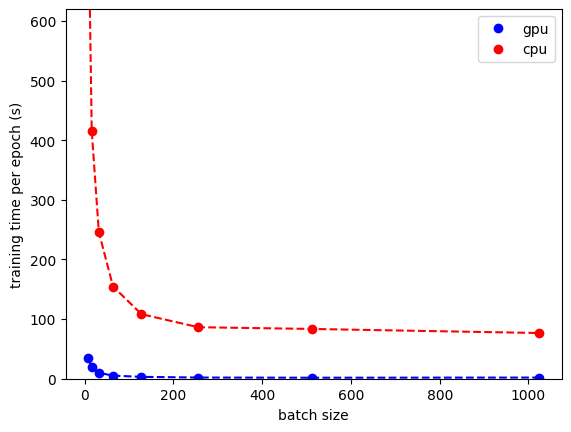

In [12]:
# plot the comparison. The training with gpu is faster by a factor of about 4-6
gpu_list=[t / 1000000000 for t in times_gpu]
cpu_list=[t / 1000000000 for t in times_cpu]
plt.plot(batch_sizes, gpu_list, 'bo')
plt.plot(batch_sizes,cpu_list,'ro')
plt.plot(batch_sizes, gpu_list, 'b--')
plt.plot(batch_sizes,cpu_list,'r--')
plt.ylabel('training time per epoch (s)')
plt.xlabel('batch size')
plt.legend(['gpu', 'cpu'], loc='upper right')
plt.ylim([0,620])
#plt.savefig('CPUvsGPU.png') 
plt.show()

In [13]:
ratio_list=[j/k for (j, k) in zip(cpu_list,gpu_list)]
ratio_list

[23.059456282633995,
 21.207166206071218,
 24.967588679293108,
 29.687906728522194,
 34.63608478613268,
 43.45581081250523,
 49.74871539953784,
 39.12542647337782]

In [14]:
get_available_gpus()

2024-12-30 19:48:34.407525: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-30 19:48:34.408977: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2024-12-30 19:48:34.415427: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 92910 MB memory:  -> device: 0, name: NVIDIA H100 NVL, pci bus id: 0000:47:00.0, compute capability: 9.0
2024-12-30 19:48:34.416884: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:1 with 92910 MB memory:  -> device: 1, name: NVIDIA H100 NVL, pci bus id: 0000:59:00.0, compute capability: 9.0


['/device:GPU:0', '/device:GPU:1']